**Fintech545 - Quantitative Risk Management**  
Midterm 1 - Felipe J  
Duke University  

### **Problem 1**

1. (20 pts) Using problem1.csv:  
a. (2) Calculate the mean, standard deviation, skewness, and kurtosis of the data.  
b. (3) Given a choice between a normal distribution and a t-distribution, which one would you choose to    
model the data? Why?    
c. (4) Fit both distributions and prove or disprove your choice in part (b).  
d. (4) Calculate the 5% and 1% VaR and ES for each distribution.  
e. (3) Calculate the 5% and 1% VaR and ES for the data using historical simulation.  
f. (4) Compare the results in parts (d) and (e). How does this line up with your choice in part (b) and results in  
part (c)?  

In [73]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

data = pd.read_csv('data/problem1.csv')
data

,X
0,-0.038791
1,-0.041258
2,0.053224
3,-0.095423
4,0.056264
...,...
995,-0.001951
996,0.008404
997,-0.033910
998,0.006430


**a. (2) Calculate the mean, standard deviation, skewness, and kurtosis of the data.**

In [19]:
# using mumpy default
print("skew", data.skew().values)
print("kurtosis", data.kurtosis().values)
print("std. dev (sigma)", data.std().values)
print("mean", data.mean().values)

# using scipy stats
print("skew", stats.skew(data))
print("kurtosis", stats.kurtosis(data))

skew [-0.23987023]
kurtosis [0.68987719]
std. dev (sigma) [0.03172784]
mean [-0.00053167]
skew [-0.23951028]
kurtosis [0.68043862]


**b. (3) Given a choice between a normal distribution and a t-distribution, which one would you choose to    
model the data? Why?**

Right off the bat we can observe thaat this distribution does not have a relatively high kurtosis (no **excess kurtosis**). This mean the distribution's PDF is unlikely to have fat tails (less relative commonality of extreme values) and we also observe a realtively normal standard deviation. **Therefore, in this case I would choose the normal distribution**.  

I've also plotted our values below. (visually, it also supports our normal distribution hypothesis).

(array([ 1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  1.,  2.,  0.,
         0.,  2.,  0.,  1.,  5.,  4.,  3.,  1.,  5.,  5.,  5.,  4.,  4.,
         7., 10.,  6.,  9., 10., 14., 14., 12., 15., 15., 19., 26., 22.,
        23., 21., 24., 24., 26., 36., 26., 40., 36., 29., 39., 27., 37.,
        28., 32., 18., 26., 27., 22., 37., 18., 18., 20., 12., 17., 12.,
        13., 17.,  8.,  8.,  7., 10.,  4.,  4.,  4.,  2.,  4.,  1.,  4.,
         3.,  2.,  2.,  4.,  2.,  0.,  0.,  0.,  1.]),
 array([-0.14852873, -0.14611982, -0.1437109 , -0.14130198, -0.13889307,
        -0.13648415, -0.13407524, -0.13166632, -0.1292574 , -0.12684849,
        -0.12443957, -0.12203066, -0.11962174, -0.11721282, -0.11480391,
        -0.11239499, -0.10998608, -0.10757716, -0.10516824, -0.10275933,
        -0.10035041, -0.09794149, -0.09553258, -0.09312366, -0.09071475,
        -0.08830583, -0.08589691, -0.083488  , -0.08107908, -0.078670

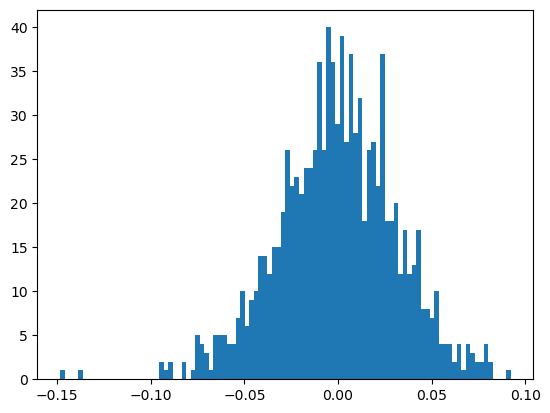

In [ ]:
plt.hist(data, 100)

**c. (4) Fit both distributions and prove or disprove your choice in part (b).**

In [ ]:
# Fitting a predetermined Distribution to data (t-distribution)

# Fit t-distribution using MLE (standard method in scipy)
# scipy.stats.t.fit returns (df, loc, scale) where df=nu, loc=mu, scale=sigma
fit_distrib = stats.t.fit(data.values) # t-distribution in this case (taking input=data)

results = pd.DataFrame(columns=['nu', 'mu', 'sigma'])
results['nu'] = [fit_distrib[0]]     # Note the brackets!
results['mu'] = [fit_distrib[1]]     # Makes it a list
results['sigma'] = [fit_distrib[2]]  # Creates 1 row

results                               # print w/ index

,nu,mu,sigma
0,13.711803,-0.000219,0.029299


In [59]:
# Fitting a predetermined Distribution to data (normal)

# Fit t-distribution using MLE (standard method in scipy)
# scipy.stats.t.fit returns (df, loc, scale) where df=nu, loc=mu, scale=sigma
fit_distrib = stats.norm.fit(data.values) # t-distribution in this case (taking input=data)
fit_distrib

results = pd.DataFrame(columns=['mu', 'sigma'])
results['mu'] = [fit_distrib[0]]     # Note the brackets!
results['sigma'] = [fit_distrib[1]]     # Makes it a list

results                               # print w/ index

,mu,sigma
0,-0.000532,0.031712


We can confirm our disitrbution is normally distributed, or at least that the parameters given assumption of normal distribution are significantly closer to the sample mean and std. deviation. **Therefore, we prove our choise, data is better modeled by a normal distribution.**

**d. (4) Calculate the 5% and 1% VaR and ES for each distribution.**  

VaR - Normal Distribution:

In [108]:
x = data['X'].values

# fit normal distribution
mu = np.mean(x)
sigma = np.std(x, ddof=1)

# VaR at 95% confidence (5th percentile)
var_absolute = -stats.norm.ppf(0.05, mu, sigma)  # absolute loss
var_diff_mean = -stats.norm.ppf(0.05, 0, sigma)  # diff from mean

result = pd.DataFrame({'VaR Absolute 5th': [var_absolute], 'VaR Diff from Mean 5th': [var_diff_mean]})
result

,VaR Absolute 5th,VaR Diff from Mean 5th
0,0.052719,0.052188


In [111]:
x = data['X'].values

# fit normal distribution
mu = np.mean(x)
sigma = np.std(x, ddof=1)

# VaR at 99% confidence (1th percentile)
var_absolute = -stats.norm.ppf(0.01, mu, sigma)  # absolute loss
var_diff_mean = -stats.norm.ppf(0.01, 0, sigma)  # diff from mean

result = pd.DataFrame({'VaR Absolute 1th': [var_absolute], 'VaR Diff from Mean 1th': [var_diff_mean]})
result

,VaR Absolute 1th,VaR Diff from Mean 1th
0,0.074342,0.07381


ES - Normal Distribution

In [ ]:
# fit normal distribution

# ES at 95% confidence from normal distribution
alpha = 0.05
z_alpha = stats.norm.ppf(alpha)  # -1.645
phi_z = stats.norm.pdf(z_alpha)   # PDF at that point

# ES formula for normal distribution
es_diff_mean = sigma * phi_z / alpha
es_absolute = -mu + sigma * phi_z / alpha

result = pd.DataFrame({
    'ES Absolute 5th': [es_absolute], 
    'ES Diff from Mean 5th': [es_diff_mean]
})

result

,ES Absolute 5th,ES Diff from Mean 5th
0,0.065977,0.065445


In [112]:
# fit normal distribution

# ES at 99% confidence from normal distribution
alpha = 0.01
z_alpha = stats.norm.ppf(alpha)  # 
phi_z = stats.norm.pdf(z_alpha)   # PDF at that point

# ES formula for normal distribution
es_diff_mean = sigma * phi_z / alpha
es_absolute = -mu + sigma * phi_z / alpha

result = pd.DataFrame({
    'ES Absolute 1th': [es_absolute], 
    'ES Diff from Mean 1th': [es_diff_mean]
})

result

,ES Absolute 1th,ES Diff from Mean 1th
0,0.085093,0.084561


VaR - T Distribution

In [113]:
# fit t distribution
params = stats.t.fit(x)
nu, mu, sigma = params[0], params[1], params[2]

# VaR at 95% confidence (5th percentile)
var_absolute = -stats.t.ppf(0.05, nu, mu, sigma)
var_diff_mean = -stats.t.ppf(0.05, nu, 0, sigma)

result = pd.DataFrame({'VaR Absolute 5th': [var_absolute], 'VaR Diff from Mean 5th': [var_diff_mean]})
result

,VaR Absolute 5th,VaR Diff from Mean 5th
0,0.051901,0.051682


In [114]:
# fit t distribution
params = stats.t.fit(x)
nu, mu, sigma = params[0], params[1], params[2]

# VaR at 99% confidence (1th percentile)
var_absolute = -stats.t.ppf(0.01, nu, mu, sigma)
var_diff_mean = -stats.t.ppf(0.01, nu, 0, sigma)

result = pd.DataFrame({'VaR Absolute 1th': [var_absolute], 'VaR Diff from Mean 1th': [var_diff_mean]})
result

,VaR Absolute 1th,VaR Diff from Mean 1th
0,0.07732,0.077101


ES - T Distribution

In [116]:
x = data['X'].values

# fit t-distribution
params = stats.t.fit(x)
nu, mu, scale = params

# ES for t-distribution at 95% confidence
alpha = 0.05
t_alpha = stats.t.ppf(alpha, nu)
pdf_t_alpha = stats.t.pdf(t_alpha, nu)

# ES formula for t-distribution
es_diff_mean = scale * (nu + t_alpha**2) / (nu - 1) * pdf_t_alpha / alpha
es_absolute = -mu + es_diff_mean

result = pd.DataFrame({
    'ES Absolute 5th': [es_absolute],
    'ES Diff from Mean 5th': [es_diff_mean]
})

result

,ES Absolute 5th,ES Diff from Mean 5th
0,0.067714,0.067495


In [117]:
x = data['X'].values

# fit t-distribution
params = stats.t.fit(x)
nu, mu, scale = params

# ES for t-distribution at 99% confidence
alpha = 0.01
t_alpha = stats.t.ppf(alpha, nu)
pdf_t_alpha = stats.t.pdf(t_alpha, nu)

# ES formula for t-distribution
es_diff_mean = scale * (nu + t_alpha**2) / (nu - 1) * pdf_t_alpha / alpha
es_absolute = -mu + es_diff_mean

result = pd.DataFrame({
    'ES Absolute 1th': [es_absolute],
    'ES Diff from Mean 1th': [es_diff_mean]
})

result

,ES Absolute 1th,ES Diff from Mean 1th
0,0.092326,0.092106


Some bonus, taken from a previous hoemwork. Side by side comparision.

Sample statistics:
Mean: X   -0.000532
dtype: float64
Std: X    0.031728
dtype: float64

[Method 1] VaR from Normal Distribution (95% confidence):
VaR Absolute: [0.05271932]
VaR Relative: [0.05218765]

[Method 2] VaR from t-Distribution (95% confidence):
Degrees of freedom: 13.711803328219464
VaR Absolute: 0.05190077607440217
VaR Relative: 0.05168162476003125

[Method 3] VaR from Simulation (95% confidence, 100k draws):
VaR Absolute: 0.052036885278225406
VaR Relative: 0.05181773396385449

=== Comparison ===
Normal vs t-dist: [0.00081854]
t-dist vs Simulation: 0.00013610920382323838
Normal vs Simulation: [0.00068243]


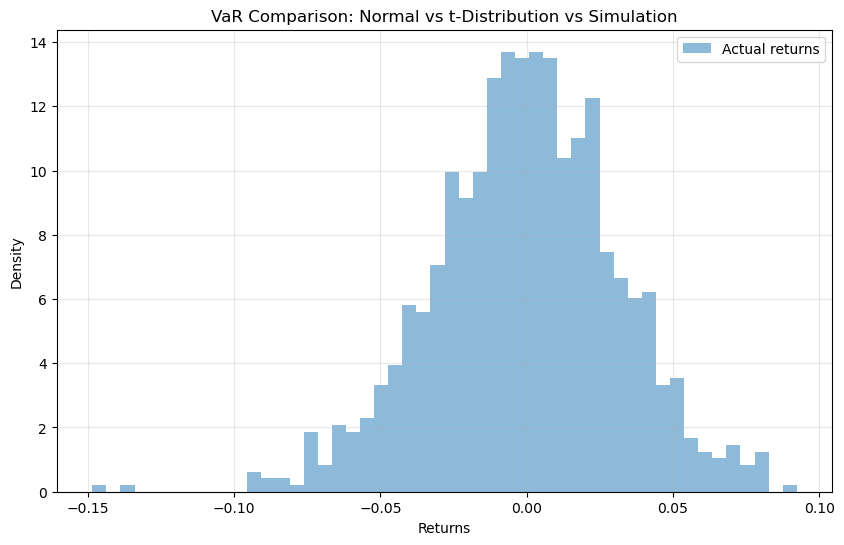

In [135]:
import numpy as np
import pandas as pd
from scipy import stats

# Generate sample returns data

params = stats.norm.fit(x)  # μ=0.1%, σ=2%
mean = data.mean()
std = data.std()

print("Sample statistics:")
print("Mean:", mean)
print("Std:", std)

# Method 1: VaR from Normal distribution
mu = data.mean()
sigma = data.std(ddof=1)

var_normal_abs = -stats.norm.ppf(0.05, mu, sigma)
var_normal_rel = -stats.norm.ppf(0.05, 0, sigma)

print("\n[Method 1] VaR from Normal Distribution (95% confidence):")
print("VaR Absolute:", var_normal_abs)
print("VaR Relative:", var_normal_rel)

# Method 2: VaR from t-distribution (heavier tails)
params = stats.t.fit(data)
nu, mu_t, sigma_t = params[0], params[1], params[2]

var_t_abs = -stats.t.ppf(0.05, nu, mu_t, sigma_t)
var_t_rel = -stats.t.ppf(0.05, nu, 0, sigma_t)

print("\n[Method 2] VaR from t-Distribution (95% confidence):")
print("Degrees of freedom:", nu)
print("VaR Absolute:", var_t_abs)
print("VaR Relative:", var_t_rel)

# Method 3: VaR from Simulation
sim_returns = stats.t.rvs(nu, mu_t, sigma_t, size=100000)

var_sim_abs = -np.percentile(sim_returns, 5)
var_sim_rel = -(np.percentile(sim_returns, 5) - mu_t)

print("\n[Method 3] VaR from Simulation (95% confidence, 100k draws):")
print("VaR Absolute:", var_sim_abs)
print("VaR Relative:", var_sim_rel)

# Compare all methods
print("\n=== Comparison ===")
print("Normal vs t-dist:", abs(var_normal_abs - var_t_abs))
print("t-dist vs Simulation:", abs(var_t_abs - var_sim_abs))
print("Normal vs Simulation:", abs(var_normal_abs - var_sim_abs))

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, alpha=0.5, label='Actual returns', density=True)
# plt.axvline(-var_normal_abs, color='blue', linestyle='--', label=f'VaR Normal: {var_normal_abs:.4f}')
# plt.axvline(-var_t_abs, color='red', linestyle='--', label=f'VaR t-dist: {var_t_abs:.4f}')
# plt.axvline(-var_sim_abs, color='green', linestyle='--', label=f'VaR Simulation: {var_sim_abs:.4f}')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.title('VaR Comparison: Normal vs t-Distribution vs Simulation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**e. (3) Calculate the 5% and 1% VaR and ES for the data using historical simulation.**

Simulation VaR/ES (T-dist)

In [119]:
# simulate using fitted t distribution and compute VaR from simulated data
x = data['X'].values

# fit t distribution
params = stats.t.fit(x)
nu, mu, sigma = params[0], params[1], params[2]

# simulate 100,000 draws from fitted t distribution
sim = stats.t.rvs(nu, mu, sigma, size=100_000)

# VaR at 95% confidence (5th percentile of simulated data)
var_absolute = -np.percentile(sim, 5)
var_diff_mean = -(np.percentile(sim, 5) - mu)

result = pd.DataFrame({'VaR Absolute 95th sim': [var_absolute], 'VaR Diff from Mean 95thsim': [var_diff_mean]})
result

,VaR Absolute 95th sim,VaR Diff from Mean 95thsim
0,0.051694,0.051475


In [121]:
# simulate 100k draws
# calculate ES from simulation
alpha = 0.05

# ES = average of all losses in the left tail (below 5th percentile)
threshold = np.percentile(sim, alpha * 100)
losses_in_tail = sim[sim <= threshold]
es_absolute = -losses_in_tail.mean()

# ES diff from mean assumes 0 mean
sim_zero_mean = stats.t.rvs(nu, 0, scale, size=100000)
threshold_zero = np.percentile(sim_zero_mean, alpha * 100)
losses_zero = sim_zero_mean[sim_zero_mean <= threshold_zero]
es_diff_mean = -losses_zero.mean()

result = pd.DataFrame({
    'ES Absolute 95th sim': [es_absolute],
    'ES Diff from Mean 95th sim': [es_diff_mean]
})
result

,ES Absolute 95th sim,ES Diff from Mean 95th sim
0,0.067661,0.067624


In [124]:
# simulate using fitted t distribution and compute VaR from simulated data
x = data['X'].values

# fit t distribution
params = stats.t.fit(x)
nu, mu, sigma = params[0], params[1], params[2]

# simulate 100,000 draws from fitted t distribution
sim = stats.t.rvs(nu, mu, sigma, size=100_000)

# VaR at 95% confidence (5th percentile of simulated data)
var_absolute = -np.percentile(sim, 1)
var_diff_mean = -(np.percentile(sim, 1) - mu)

result = pd.DataFrame({'VaR Absolute 99th sim': [var_absolute], 'VaR Diff from Mean 99th sim': [var_diff_mean]})
result

,VaR Absolute 99th sim,VaR Diff from Mean 99th sim
0,0.077724,0.077505


In [126]:
# simulate 100k draws
# calculate ES from simulation
alpha = 0.01

# ES = average of all losses in the left tail (below 5th percentile)
threshold = np.percentile(sim, alpha * 100)
losses_in_tail = sim[sim <= threshold]
es_absolute = -losses_in_tail.mean()

# ES diff from mean assumes 0 mean
sim_zero_mean = stats.t.rvs(nu, 0, scale, size=100000)
threshold_zero = np.percentile(sim_zero_mean, alpha * 100)
losses_zero = sim_zero_mean[sim_zero_mean <= threshold_zero]
es_diff_mean = -losses_zero.mean()

result = pd.DataFrame({
    'ES Absolute 99th sim': [es_absolute],
    'ES Diff from Mean 99th sim': [es_diff_mean]
})
result

,ES Absolute 99th sim,ES Diff from Mean 99th sim
0,0.092642,0.090569


Simulation VaR/ES (normal distrib)

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# simulate VaR using fitted normal distribution and compute VaR from simulated data


x = data['X'].values

# fit norm distribution
params = stats.t.fit(x)
mu = x.mean()
sigma = x.std(ddof=1)

# simulate 100,000 draws from fitted t distribution
sim = stats.norm.rvs(mu, sigma, 100_000)

# VaR at 95% confidence (5th percentile of simulated data)
var_absolute = -np.percentile(sim, 5)
var_diff_mean = -(np.percentile(sim, 5) - mu)

result = pd.DataFrame({'VaR Absolute 95th': [var_absolute], 'VaR Diff from Mean 95th': [var_diff_mean]})

print(result)

   VaR Absolute  VaR Diff from Mean
0      0.052822            0.052291


In [134]:
x = data['X'].values

# fit norm distribution
params = stats.t.fit(x)
mu = x.mean()
sigma = x.std(ddof=1)

# simulate 100,000 draws from fitted t distribution
sim = stats.norm.rvs(mu, sigma, 100_000)

# VaR at 99% confidence (1th percentile of simulated data)
var_absolute = -np.percentile(sim, 1)
var_diff_mean = -(np.percentile(sim, 1) - mu)

result = pd.DataFrame({'VaR Absolute 99th': [var_absolute], 'VaR Diff from Mean 99th': [var_diff_mean]})

print(result)

   VaR Absolute 99th  VaR Diff from Mean 99th
0           0.074144                 0.073612


In [128]:
# ES from simulation
x = data['X'].values
mu = x.mean()
sigma = np.std(x, ddof=1)

# Simulate 100k draws
sim = stats.norm.rvs(mu, sigma)

# Calculate ES (95th)
alpha = 0.05
var_sim = -np.percentile(sim, alpha * 100)

# ES = average of losses beyond VaR
losses_beyond_var = sim[sim <= -var_sim]
es_absolute = -losses_beyond_var.mean()

# For ES diff from mean, simulate with μ=0
sim_zero_mean = stats.norm.rvs(0, sigma, size=100000)
threshold_zero = np.percentile(sim_zero_mean, alpha * 100)
losses_zero = sim_zero_mean[sim_zero_mean <= threshold_zero]
es_diff_mean = -losses_zero.mean()

result = pd.DataFrame({
    'ES Absolute 95th sim': [es_absolute],
    'ES Diff from Mean 95th sim': [es_diff_mean]
})

result

,ES Absolute 95th sim,ES Diff from Mean 95th sim
0,-0.010227,0.065284


In [130]:
# ES from simulation
x = data['X'].values
mu = x.mean()
sigma = np.std(x, ddof=1)

# Simulate 100k draws
sim = stats.norm.rvs(mu, sigma)

# Calculate ES (95th)
alpha = 0.01
var_sim = -np.percentile(sim, alpha * 100)

# ES = average of losses beyond VaR
losses_beyond_var = sim[sim <= -var_sim]
es_absolute = -losses_beyond_var.mean()

# For ES diff from mean, simulate with μ=0
sim_zero_mean = stats.norm.rvs(0, sigma, size=100000)
threshold_zero = np.percentile(sim_zero_mean, alpha * 100)
losses_zero = sim_zero_mean[sim_zero_mean <= threshold_zero]
es_diff_mean = -losses_zero.mean()

result = pd.DataFrame({
    'ES Absolute 99th sim': [es_absolute],
    'ES Diff from Mean 99th sim': [es_diff_mean]
})

result

,ES Absolute 99th sim,ES Diff from Mean 99th sim
0,-0.038892,0.084654


f. (4) Compare the results in parts (d) and (e). How does this line up with your choice in part (b) and results in  
part (c)? 

In [ ]:
# Lets compare the outputs:

# [Method 1] VaR from Normal Distribution (95% confidence):
# VaR Absolute: [0.05271932]
# VaR Relative: [0.05218765]

# [Method 1] ES norm-distrib:
# 	ES Absolute 5th	ES Diff from Mean 5th
# 0	0.065977	         0.065445



# [Method 1] VaR from t-Distribution (95% confidence):
# Degrees of freedom: 13.711803328219464
# VaR Absolute: 0.05190077607440217
# VaR Relative: 0.05168162476003125

# [Method 1] ES t-distrib:
# 	ES Absolute 5th	ES Diff from Mean 5th
# 0	0.067714	          0.067495




# [Method 2] VaR ad ES from simulation:

#    VaR Absolute  VaR Diff from Mean 
# 0      0.052822            0.052291


# ES Absolute 95th sim	 ES Diff from Mean 95th sim
# 0	0.067661	          0.067624


The simulation for VaR supports our conclusion that the distribution is relatively normal. However, it is worth it to note that ES simulation fall closer to the t-distribution values, which is likely because ES itself is a measure of extreme values- where, given VaR exceeded, what is the average loss.

### Problem 2

### Problem 3

Using problem3.csv:  
You are given the input covariance matrix and need to use it for risk analysis.  
a. (5) Calculate the eigenvalues of the covariance matrix. What do you see?  
b. (5) Calculate the nearest PSD matrix using Higham's algorithm. How does this change the eigenvalues?  
c. (5) Calculate the nearest PSD matrix using the Near PSD method of Rebonato and Jackel. How does this change the eigenvalues?    
d. (5) Compare the results in parts (b) and (c). Which method do you prefer and why?  

In [225]:
covar = pd.read_csv('data/problem3.csv')
# Near_PSD for CoVar and Corr matrices (Higham) ------------- Method 2 ------------

import numpy as np
import pandas as pd
from numpy.linalg import eigh

input_matrix = covar

# Higham's algorithm for nearest PSD matrix
def higham_psd(matrix, max_iterations=100, tol=1e-9):
    n = matrix.shape[0]
    
    # check if covariance or correlation
    invSD = None
    out = matrix.copy()
    
    if not np.allclose(np.diag(out), 1.0):
        invSD = np.diag(1.0 / np.sqrt(np.diag(out)))
        out = invSD @ out @ invSD
    
    # initialize
    Y = out.copy()
    Delta_S = np.zeros((n, n))
    prev_norm = np.inf
    
    for iteration in range(max_iterations):
        # project to PSD (fix negative eigenvalues)
        R = Y - Delta_S
        vals, vecs = eigh(R)
        vals = np.maximum(vals, 0)  # set negative to 0
        X = vecs @ np.diag(vals) @ vecs.T
        
        Delta_S = X - R
        
        # project to unit diagonal (set diagonal to 1)
        Y = X.copy()
        np.fill_diagonal(Y, 1.0)
        
        # check convergence
        norm = np.linalg.norm(Y - out, 'fro')
        if abs(norm - prev_norm) < tol:
            break
        prev_norm = norm
    
    out = Y
    
    # convert back to covariance if needed
    if invSD is not None:
        invSD = np.diag(1.0 / np.diag(invSD))
        out = invSD @ out @ invSD
    
    return out


# fix using Higham
result = higham_psd(covar)
result

array([[ 3.37587955e-04,  3.45671879e-04, -6.78109753e-05,
        -4.28634933e-05, -3.62002631e-05],
       [ 3.45671879e-04,  5.01453173e-04,  2.01491584e-06,
        -1.62239938e-04,  5.46520754e-05],
       [-6.78109753e-05,  2.01491584e-06,  1.89132830e-04,
        -1.01157795e-04, -4.63366145e-05],
       [-4.28634933e-05, -1.62239938e-04, -1.01157795e-04,
         4.03088547e-04, -2.92798219e-05],
       [-3.62002631e-05,  5.46520754e-05, -4.63366145e-05,
        -2.92798219e-05,  1.29161672e-04]])

In [224]:
# Near_PSD for CoVar and Corr matrices (Spectral) ------------- Method 1 ------------
import numpy as np
import pandas as pd
from numpy.linalg import eigh

input_matrix = pd.read_csv('data/problem3.csv')

# fix non-PSD matrix using Rebonato-Jackel method
def near_psd(matrix, epsilon=0.0):
    n = matrix.shape[0]
    
    # check if it's a correlation matrix (diagonal = 1) or covariance
    invSD = None
    out = matrix.copy()
    
    # if covariance, convert to correlation
    if not np.allclose(np.diag(out), 1.0):
        invSD = np.diag(1.0 / np.sqrt(np.diag(out)))
        out = invSD @ out @ invSD
    
    # eigenvalue decomposition
    vals, vecs = eigh(out)
    
    # set negative eigenvalues to epsilon (or 0)
    vals = np.maximum(vals, epsilon)
    
    # reconstruct with scaling matrix T
    T = 1.0 / (vecs ** 2 @ vals)
    T = np.diag(np.sqrt(T))
    
    B = T @ vecs @ np.diag(np.sqrt(vals))
    out = B @ B.T
    
    # convert back to covariance if needed
    if invSD is not None:
        invSD = np.diag(1.0 / np.diag(invSD))
        out = invSD @ out @ invSD
    
    return out

# read the non-PSD matrix from 1.3
# read the non-PSD correlation matrix from 1.4
# matrix = input_matrix.values

# fix it
result = near_psd(input_matrix)
result

array([[ 3.37587955e-04,  3.39765563e-04, -6.84555942e-05,
        -4.11223920e-05, -3.79550502e-05],
       [ 3.39765563e-04,  5.01453173e-04,  5.53655712e-06,
        -1.58480718e-04,  5.64024953e-05],
       [-6.84555942e-05,  5.53655712e-06,  1.89132830e-04,
        -1.00356858e-04, -4.64565111e-05],
       [-4.11223920e-05, -1.58480718e-04, -1.00356858e-04,
         4.03088547e-04, -2.88685813e-05],
       [-3.79550502e-05,  5.64024953e-05, -4.64565111e-05,
        -2.88685813e-05,  1.29161672e-04]])

### Problem 4

Using the price data in problem4.csv:  
* You hold a portfolio with a current value of \$100,000.    
a. (5) Calculate the number of shares (fractions of shares are OK) of each of these stocks in your portfolio so that each stock has an equal weight.    
b. (10) Calculate the daily returns of each stock using arithmetic returns. Show the first 5 rows and last 5 rows of the return data.  
c. (15) Remove the mean from each series. Fit both a normal and a t-distribution to the returns of each stock. Show the parameters of best fit for each stock.  
d. (30) Calculate the 1% VaR and ES for each stock and the portfolio as $ values. Use a Gaussian copula to model the dependence structure between the stocks. Calculate the 1% VaR and ES using a historical simulation as well. Present the results in a table and compare the results. Which method do you prefer and why?  

In [203]:
# a. (5) Calculate the number of shares (fractions of shares are OK) of each of these stocks in your portfolio so that each stock has an equal weight.    
data_p4 = pd.read_csv('data/problem4.csv')
data_p4

,Date,SPY,AAPL,MSFT,GOOGL,BABA
0,2022-01-03,451.875183,178.103668,323.898376,143.904205,114.324287
1,2022-01-04,451.723785,175.843262,318.344513,143.316650,113.545532
2,2022-01-05,443.049805,171.165817,306.123901,136.741821,115.065048
3,2022-01-06,442.633514,168.308487,303.704895,136.714508,120.259880
4,2022-01-07,440.883575,168.474838,303.859802,135.989517,123.279907
...,...,...,...,...,...,...
1032,2026-02-13,681.750000,255.779999,401.320007,305.720001,155.729996
1033,2026-02-17,682.849976,263.880005,396.859985,302.019989,155.429993
1034,2026-02-18,686.289978,264.350006,399.600006,303.329987,155.770004
1035,2026-02-19,684.479980,260.579987,398.459991,302.850006,154.270004


In [ ]:
# if each stock has an equal weight, then Portfolio Value / n_stocks = w_i (in the last row of data)
n_stocks = 5
portfolio_value = 100_000

w_i = portfolio_value / n_stocks # units dollars 
stocks = data_p4.columns[1:]

shares_apple = ((w_i / data_p4['AAPL'].iloc[-1]))
shares_google = ((w_i / data_p4['GOOGL'].iloc[-1]))
shares_spy = ((w_i / data_p4['SPY'].iloc[-1]))
shares_baba = ((w_i / data_p4['BABA'].iloc[-1]))
shares_msft = ((w_i / data_p4['MSFT'].iloc[-1]))


In [205]:
print('AAPL shares:', shares_apple)
print('GOOGL shares:', shares_google)
print('SPY shares:', shares_spy)
print('BABA shares:', shares_baba)
print('MSFT shares:', shares_msft)

AAPL shares: 75.59150735135944
GOOGL shares: 63.49609277544952
SPY shares: 29.009471900659555
BABA shares: 129.49174745987344
MSFT shares: 50.348663109163624


In [206]:
# b. (10) Calculate the daily returns of each stock using arithmetic returns. Show the first 5 rows and last 5 rows of the return data.
# calculate Arithmetic returns for each column except Date
returns = data_p4.copy()
for col in returns.columns[1:]: # skip Date column
    returns[col] = returns[col].pct_change()  # note first row will be NaN as it has no previous data
     
returns = returns.dropna()
returns.head(n = 5)

,Date,SPY,AAPL,MSFT,GOOGL,BABA
1,2022-01-04,-0.000335,-0.012692,-0.017147,-0.004083,-0.006812
2,2022-01-05,-0.019202,-0.026600,-0.038388,-0.045876,0.013382
3,2022-01-06,-0.000940,-0.016693,-0.007902,-0.000200,0.045147
4,2022-01-07,-0.003953,0.000988,0.000510,-0.005303,0.025113
5,2022-01-10,-0.001244,0.000116,0.000733,0.012060,-0.011632


In [208]:
returns.iloc[:-5]

,Date,SPY,AAPL,MSFT,GOOGL,BABA
1,2022-01-04,-0.000335,-0.012692,-0.017147,-0.004083,-0.006812
2,2022-01-05,-0.019202,-0.026600,-0.038388,-0.045876,0.013382
3,2022-01-06,-0.000940,-0.016693,-0.007902,-0.000200,0.045147
4,2022-01-07,-0.003953,0.000988,0.000510,-0.005303,0.025113
5,2022-01-10,-0.001244,0.000116,0.000733,0.012060,-0.011632
...,...,...,...,...,...,...
1027,2026-02-06,0.019185,0.008010,0.018975,-0.025328,0.030109
1028,2026-02-09,0.004822,-0.011661,0.031061,0.004522,0.003015
1029,2026-02-10,-0.002637,-0.003423,-0.000798,-0.017699,0.021534
1030,2026-02-11,-0.000231,0.006650,-0.021536,-0.023919,-0.013152


**c. (15) Remove the mean from each series. Fit both a normal and a t-distribution to the returns of each stock. Show the parameters of best fit for each stock.**


In [209]:
import scipy 

returns_demean = returns.copy()
for col in returns.columns[1:]: # skip Date column
    returns_demean[col] = scipy.signal.detrend(returns[col], type='constant') # deman data

returns_demean.iloc[:-5]


,Date,SPY,AAPL,MSFT,GOOGL,BABA
1,2022-01-04,-0.000806,-0.013234,-0.017491,-0.005047,-0.007629
2,2022-01-05,-0.019673,-0.027142,-0.038732,-0.046840,0.012565
3,2022-01-06,-0.001410,-0.017236,-0.008246,-0.001164,0.044330
4,2022-01-07,-0.004424,0.000446,0.000166,-0.006267,0.024295
5,2022-01-10,-0.001715,-0.000426,0.000388,0.011096,-0.012449
...,...,...,...,...,...,...
1027,2026-02-06,0.018714,0.007468,0.018631,-0.026292,0.029292
1028,2026-02-09,0.004351,-0.012203,0.030717,0.003558,0.002198
1029,2026-02-10,-0.003108,-0.003965,-0.001142,-0.018663,0.020717
1030,2026-02-11,-0.000702,0.006108,-0.021880,-0.024883,-0.013969


Fit t Distrbution

In [216]:
fit_t_distrib = returns_demean.copy()
for col in returns.columns[1:]: # skip Date column
    fit_t_distrib['param0'], fit_t_distrib['param1'], fit_t_distrib['param2'] = stats.t.fit(returns_demean[col]) # fit t-distrib to each stock
    
fit_t_distrib



,Date,SPY,AAPL,MSFT,GOOGL,BABA,param0,param1,param2
1,2022-01-04,-0.000806,-0.013234,-0.017491,-0.005047,-0.007629,3.125143,-0.00216,0.02077
2,2022-01-05,-0.019673,-0.027142,-0.038732,-0.046840,0.012565,3.125143,-0.00216,0.02077
3,2022-01-06,-0.001410,-0.017236,-0.008246,-0.001164,0.044330,3.125143,-0.00216,0.02077
4,2022-01-07,-0.004424,0.000446,0.000166,-0.006267,0.024295,3.125143,-0.00216,0.02077
5,2022-01-10,-0.001715,-0.000426,0.000388,0.011096,-0.012449,3.125143,-0.00216,0.02077
...,...,...,...,...,...,...,...,...,...
1032,2026-02-13,0.000234,-0.023276,-0.001638,-0.011579,-0.019717,3.125143,-0.00216,0.02077
1033,2026-02-17,0.001143,0.031126,-0.011458,-0.013067,-0.002744,3.125143,-0.00216,0.02077
1034,2026-02-18,0.004567,0.001239,0.006560,0.003373,0.001370,3.125143,-0.00216,0.02077
1035,2026-02-19,-0.003108,-0.014804,-0.003197,-0.002546,-0.010447,3.125143,-0.00216,0.02077


In [230]:
fjpisfat = pd.DataFrame()
fjpisfat['gay'] = ['yaaaas']

fjpisfat


,gay
0,yaaaas
